# GBD_12 — Thin lens via q-parameter transformation + brief aperture demo (Era 3, step 1)

**The first Era 3 notebook.** Introduces the thin-element framework: how do we apply optical elements (lens, aperture) to a beam in GBD?

**Scope (per the design discussion in DISCUSSION_LOG.md):**
- Single 2-D Gaussian beam representation (no basis sum needed yet — that comes back in GBD_13 with the target return).
- Demonstrate **thin lens** via per-beamlet q-parameter transformation: `1/q' = 1/q − 1/f`. This is the elegant signature of GBD — a single complex-arithmetic operation handles a full optical element.
- Demonstrate **hard aperture** via grid multiplication. Note that the post-aperture field is no longer a pure Gaussian, so this approach only works downstream if we re-decompose into a basis (deferred to GBD_13).
- Validate the lens transformation against an angular-spectrum (AS) reference doing the same chain on the grid.

**The optical chain in this notebook:**
```
Source (1 mm Gaussian) → TX lens (f=1m) → TX aperture (10mm) → free space (100m) → RX aperture (25mm)
```

**Predicted behavior** (computed analytically in CONCEPTS.md Topic 6 — should match what we measure here):
- After lens at z=0+: q transforms from `−2.027i` to `−0.804 − 0.397i` (lens at z=0 with f=1m).
- New (focused) waist at z = 0.804 m, w_new = 0.442 mm.
- New Rayleigh range zR' = 0.397 m.
- Beam expands rapidly past new waist; at z=100 m, w(100) ≈ 110 mm.
- TX aperture (10mm) barely affects 1mm source — minimal truncation.
- RX aperture (25mm) at z=100m where beam is 110mm wide: dramatic clip, ~2.5% energy transmitted.

**Sanity checks performed below:**
1. Source at z=0 (GBD analytic vs. direct evaluation): ~1e-15.
2. Post-lens at z=0+ (GBD analytic vs. source × lens phase via AS): ~1e-15.
3. Free-space propagated to z=2 m (GBD analytic vs. AS): expect ~3×10⁻³ relative error due to AS chirp-aliasing. **GBD is the analytically-exact reference; AS is the one with discretization error here.**
4. Free-space propagated to z=100 m: same chirp-aliasing floor (~3×10⁻³). Independent of z.
5. After TX aperture: identical operation in both (grid multiplication).
6. After RX aperture at z=100 m: same.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- LiDAR / Era 3 parameters ---
wavelength = 1550e-9         # 1550 nm (carry from Era 2)
w0_source  = 1.0e-3          # 1 mm source waist
k          = 2*np.pi / wavelength
zR_source  = np.pi * w0_source**2 / wavelength    # 2.027 m
theta_div  = wavelength / (np.pi * w0_source)

# --- Optical chain parameters (locked in DISCUSSION_LOG Era 3 table) ---
D_TX = 10e-3                 # TX aperture diameter, 10 mm
D_RX = 25e-3                 # RX aperture diameter, 25 mm
f_lens = 1.0                 # TX lens focal length, 1 m (chosen for visual clarity)
z_lens = 0.0                 # lens position (immediately at source plane)
R_target = 100.0             # nominal target / RX plane distance, 100 m

print(f'wavelength       = {wavelength*1e9:.1f} nm')
print(f'w0_source        = {w0_source*1e3:.3f} mm')
print(f'zR_source        = {zR_source:.4f} m')
print(f'theta_div        = {theta_div:.3e} rad   (paraxial OK)')
print(f'\nOptical chain:')
print(f'  TX lens at z={z_lens:.3f} m, focal length f = {f_lens:.3f} m')
print(f'  TX aperture (D = {D_TX*1e3:.1f} mm)')
print(f'  RX plane at z = {R_target:.1f} m, RX aperture (D = {D_RX*1e3:.1f} mm)')

wavelength       = 1550.0 nm
w0_source        = 1.000 mm
zR_source        = 2.0268 m
theta_div        = 4.934e-04 rad   (paraxial OK)

Optical chain:
  TX lens at z=0.000 m, focal length f = 1.000 m
  TX aperture (D = 10.0 mm)
  RX plane at z = 100.0 m, RX aperture (D = 25.0 mm)


In [2]:
# --- 2-D grid sized for source resolution + long-z beam containment ---
# At z=100m, w(z) for the post-lens beam (zR'=0.397m, w_new=0.442mm at z_w=0.804m):
# w(100) = w_new * sqrt(1 + ((100-0.804)/0.397)^2) ~ 110 mm. Need grid ±300mm for ~3 sigma.
Lx = Ly = 300e-3              # ±300 mm
Nx = Ny = 2049                # odd → exact origin sample
x = np.linspace(-Lx, Lx, Nx)
y = np.linspace(-Ly, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='xy')
dx = x[1] - x[0]

print(f'Grid: {Nx}x{Ny}, x in [{-Lx*1e3:.0f}, {Lx*1e3:.0f}] mm')
print(f'dx = {dx*1e6:.1f} um')
# Standing diagnostic per Surprise 6: verify source is well-sampled
print(f'samples per source w0 radius      = {w0_source/dx:.2f}   (>= 2 = OK)')
# We compute the predicted post-lens waist below and check it too
print(f'\nMemory per complex field: {Nx*Ny*16/1e6:.1f} MB')

Grid: 2049x2049, x in [-300, 300] mm
dx = 293.0 um
samples per source w0 radius      = 3.41   (>= 2 = OK)

Memory per complex field: 67.2 MB


## Beam state representation

We represent a Gaussian beam by its **state**: a dictionary holding all the parameters that fully determine the beam at every z.

- `q_anchor` (complex): the q-parameter at z = z_anchor. For a fresh source at its waist, q_anchor = −i·zR.
- `z_anchor` (float): the z at which q_anchor is referenced. Updates whenever a thin element acts.
- `x_anchor`, `y_anchor` (float): transverse position at z_anchor.
- `kx`, `ky` (float): transverse wavevector. Updates when an off-axis beam meets a lens.

From this state, the field at any z can be computed analytically — that's what the propagator function below does.

In [3]:
def make_source_state(w0, k, x0=0.0, y0=0.0, kx=0.0, ky=0.0, z0=0.0):
    """Build the state for a fresh Gaussian source at its waist."""
    wl = 2*np.pi/k
    zR = np.pi * w0**2 / wl
    return dict(q_anchor=-1j*zR, z_anchor=z0, x_anchor=x0, y_anchor=y0, kx=kx, ky=ky)

def evaluate_beam_state(state, X, Y, k, z):
    """Evaluate the field of a beam state at distance z on the (X, Y) grid.
    
    The propagator is the same as GBD_9's, but generalized to arbitrary anchor
    state (not just a waist at z=0). The math:
        Δz = z - z_anchor
        q(z) = Δz + q_anchor
        x_c = x_anchor + (kx/k) * Δz
        E = (q_anchor / q(z)) * exp(i·k·((X-x_c)² + (Y-y_c)²) / (2·q(z))) 
            * exp(i·kz·Δz) * exp(i·(kx·X + ky·Y))
    """
    q_anchor = state['q_anchor']
    z_anchor = state['z_anchor']
    x_anchor = state['x_anchor']
    y_anchor = state['y_anchor']
    kx = state['kx']
    ky = state['ky']
    
    dz = z - z_anchor
    q_at_z = dz + q_anchor
    x_c = x_anchor + (kx/k) * dz
    y_c = y_anchor + (ky/k) * dz
    
    transverse = (q_anchor / q_at_z) * np.exp(1j * k * ((X-x_c)**2 + (Y-y_c)**2) / (2 * q_at_z))
    kz = np.sqrt(k**2 - kx**2 - ky**2)
    longitudinal = np.exp(1j * kz * dz)
    tilt = np.exp(1j * (kx*X + ky*Y))
    return transverse * longitudinal * tilt

## Sanity 1: source at z = 0 matches direct evaluation

The source state at z=0 should reproduce a clean 2-D Gaussian. Compare against direct evaluation.

In [4]:
source_state = make_source_state(w0_source, k)
print(f'Source state: q_anchor = {source_state["q_anchor"]:.4f}, z_anchor = {source_state["z_anchor"]}')

E_source_state = evaluate_beam_state(source_state, X, Y, k, z=0.0)
E_source_direct = np.exp(-(X**2 + Y**2) / w0_source**2).astype(complex)

diff = np.max(np.abs(E_source_state - E_source_direct))
print(f'\n[Sanity 1] Max |evaluate_beam_state(z=0) - direct Gaussian| = {diff:.3e}')
print('(should be ~1e-15)')

Source state: q_anchor = 0.0000-2.0268j, z_anchor = 0.0

[Sanity 1] Max |evaluate_beam_state(z=0) - direct Gaussian| = 1.110e-16
(should be ~1e-15)


## The thin-lens transformation

When a thin lens acts at z = z_lens with focal length f:
- Compute the q-parameter just before the lens: `q_at_lens = (z_lens − z_anchor) + q_anchor`.
- Compute the transverse position at z_lens: `x_at_lens = x_anchor + (kx/k)·(z_lens − z_anchor)`.
- Update q via `1/q_after = 1/q_at_lens − 1/f`.
- Update kx, ky to redirect off-axis beams toward focus: `kx_new = kx − k·x_at_lens/f`.
- New anchor: `z_anchor → z_lens`, `q_anchor → q_after`, `x_anchor → x_at_lens`, `y_anchor → y_at_lens`.

All of this is one simple state update — no FFTs, no integration, no decomposition. That's GBD's elegance for thin elements.

In [5]:
def apply_thin_lens(state, f, z_lens, k):
    """Apply a thin lens with focal length f at position z_lens.
    Returns a new state. (Doesn't modify the input.)"""
    dz = z_lens - state['z_anchor']
    q_at_lens = dz + state['q_anchor']
    x_at_lens = state['x_anchor'] + (state['kx']/k) * dz
    y_at_lens = state['y_anchor'] + (state['ky']/k) * dz
    
    # q-transformation: 1/q' = 1/q - 1/f
    one_over_q_after = 1.0 / q_at_lens - 1.0 / f
    q_after = 1.0 / one_over_q_after
    
    # kx, ky redirection: lens deflects off-axis rays toward focus
    kx_new = state['kx'] - k * x_at_lens / f
    ky_new = state['ky'] - k * y_at_lens / f
    
    return dict(
        q_anchor = q_after,
        z_anchor = z_lens,
        x_anchor = x_at_lens,
        y_anchor = y_at_lens,
        kx = kx_new,
        ky = ky_new,
    )

# Apply to our source
post_lens_state = apply_thin_lens(source_state, f=f_lens, z_lens=z_lens, k=k)
print(f'Pre-lens state:  q_anchor = {source_state["q_anchor"]:+.4f}, z_anchor = {source_state["z_anchor"]:.4f} m')
print(f'Post-lens state: q_anchor = {post_lens_state["q_anchor"]:+.4f}, z_anchor = {post_lens_state["z_anchor"]:.4f} m')

# Interpret the new q
q_after = post_lens_state['q_anchor']
z_w_new = z_lens - q_after.real
zR_new = -q_after.imag
w_new = np.sqrt(wavelength * zR_new / np.pi)
print(f'\nNew waist position: z = {z_w_new:.4f} m')
print(f'New Rayleigh range: zR = {zR_new:.4f} m')
print(f'New waist size:     w = {w_new*1e3:.3f} mm')
print(f'\n(Predicted in CONCEPTS.md Topic 6 worked example: z_w=0.804m, zR=0.397m, w=0.442mm.)')
# Standing diagnostic
print(f'samples per post-lens waist radius = {w_new/dx:.2f}   (acceptable if >= 1.5)')

Pre-lens state:  q_anchor = +0.0000-2.0268j, z_anchor = 0.0000 m
Post-lens state: q_anchor = -0.8042-0.3968j, z_anchor = 0.0000 m

New waist position: z = 0.8042 m
New Rayleigh range: zR = 0.3968 m
New waist size:     w = 0.442 mm

(Predicted in CONCEPTS.md Topic 6 worked example: z_w=0.804m, zR=0.397m, w=0.442mm.)
samples per post-lens waist radius = 1.51   (acceptable if >= 1.5)


## Sanity 2: Post-lens at z = 0+ vs. direct lens × source

Immediately after the lens, the field should equal `source × exp(−i·k·r²/(2f))`. Two ways to compute this:
1. **GBD analytic**: evaluate post-lens state at z = z_lens.
2. **Direct**: take the source field and multiply by the lens phase function.

These must agree. (This is essentially a unit test of the lens-q-update formula.)

In [6]:
# GBD analytic post-lens at z = z_lens
E_postlens_GBD = evaluate_beam_state(post_lens_state, X, Y, k, z=z_lens)

# Direct: source × lens phase
lens_phase = np.exp(-1j * k * (X**2 + Y**2) / (2 * f_lens))
E_postlens_direct = E_source_direct * lens_phase

diff = np.max(np.abs(E_postlens_GBD - E_postlens_direct))
print(f'[Sanity 2] Max |GBD post-lens at z={z_lens} - source × lens phase| = {diff:.3e}')
print('(should be ~1e-15 — the lens-q formula is correct iff this passes)')

[Sanity 2] Max |GBD post-lens at z=0.0 - source × lens phase| = 1.570e-16
(should be ~1e-15 — the lens-q formula is correct iff this passes)


## The 2-D AS propagator (carried over from GBD_11)

Used as the independent reference for free-space propagation.

In [7]:
def propagate_angular_spectrum_2d(E0, x, y, k, z):
    """2-D AS propagator. Reference for free-space scalar diffraction."""
    Nx_loc, Ny_loc = len(x), len(y)
    dx_loc = x[1] - x[0]
    dy_loc = y[1] - y[0]
    kx_grid = 2*np.pi * np.fft.fftfreq(Nx_loc, d=dx_loc)
    ky_grid = 2*np.pi * np.fft.fftfreq(Ny_loc, d=dy_loc)
    KX, KY = np.meshgrid(kx_grid, ky_grid, indexing='xy')
    KZ = np.sqrt((k**2 - KX**2 - KY**2).astype(complex))
    return np.fft.ifft2(np.fft.fft2(E0) * np.exp(1j * KZ * z))

## Sanity 3: Free-space propagation of the post-lens beam — GBD vs. AS at multiple z

Propagate the post-lens beam to z = 2 m and z = 100 m. Compare GBD analytic to AS-of-(source × lens-phase).

Both methods should be evaluating the same field, but with different discretization treatment of the lens phase. **What we will find:** GBD analytic = exact answer; AS gives a ~0.3% deviation due to chirp aliasing on the discrete grid. This turns out to be informative — it surfaces a real AS limitation that GBD overcomes.

In [8]:
def compare_at_z(z_test, post_lens_state, E_postlens_grid, X, Y, k, x, y):
    """Compute and compare GBD analytic vs. AS at a given z."""
    # GBD analytic: evaluate post-lens state at z
    E_GBD = evaluate_beam_state(post_lens_state, X, Y, k, z=z_test)
    # AS: propagate the post-lens-source-plane field (= source × lens phase) by z_test - z_lens
    z_anchor = post_lens_state['z_anchor']
    E_AS = propagate_angular_spectrum_2d(E_postlens_grid, x, y, k, z=z_test - z_anchor)
    # Compare
    L2_rel = np.linalg.norm(E_GBD - E_AS) / np.linalg.norm(E_AS)
    max_abs = np.max(np.abs(E_GBD - E_AS))
    return E_GBD, E_AS, L2_rel, max_abs

# Compare at multiple z
z_tests = [z_lens, 0.5, 2.0, 10.0, R_target]
print(f"{'z [m]':>8s}  {'L2 rel':>11s}  {'max abs':>11s}  {'comment':>30s}")
for z_t in z_tests:
    E_GBD_z, E_AS_z, L2, mx = compare_at_z(z_t, post_lens_state, E_postlens_direct, X, Y, k, x, y)
    # Predicted width at z
    dz = z_t - z_lens
    q_at_z = dz + q_after
    w_at_z = np.sqrt(wavelength / (np.pi * (1/q_at_z).imag))
    note = f'w(z) = {w_at_z*1e3:.3f} mm'
    print(f'{z_t:8.3f}  {L2:11.3e}  {mx:11.3e}  {note:>30s}')

   z [m]       L2 rel      max abs                         comment
   0.000    9.471e-16    5.411e-16                 w(z) = 1.000 mm
   0.500    2.216e-03    1.892e-03                 w(z) = 0.558 mm
   2.000    2.833e-03    9.570e-04                 w(z) = 1.405 mm
  10.000    2.888e-03    2.062e-04                w(z) = 10.264 mm
 100.000    2.871e-03    3.510e-05               w(z) = 110.613 mm


## Sanity 3 result interpretation: AS chirp-aliasing

**Surprise:** the GBD-vs-AS L2 rel is ~3×10⁻³ at z>0, not the machine precision predicted in the markdown intro. Diagnosed via focal-length sweep below.

**Root cause:** the lens phase function `exp(−i·k·r²/(2f))` has local spatial frequency `k·r/f`. For f=1m, our 2049-pt grid with dx=293µm has Nyquist `π/dx = 1.07×10⁷ rad/m`. The lens-phase frequency exceeds Nyquist for `r > π·f/(k·dx) = 2.65 mm`. **The lens phase is aliased on the discrete grid for r > 2.65 mm.**

Even though the source amplitude is essentially zero past r ~ 5mm, the aliased phase samples mix into the FFT during AS propagation and produce a ~0.3% error. This is a well-known limitation of AS with chirp functions.

**GBD doesn't have this problem.** GBD propagates the q-parameter analytically — no FFT, no aliasing. Sanity 1 (state vs. direct Gaussian) and Sanity 2 (q-update vs. direct lens-phase multiplication) both passed at machine precision, so GBD is computing the analytically-exact answer.

Confirming with a focal-length sweep:

In [9]:
# Focal-length sweep: as f grows, r_alias = pi*f/(k*dx) grows, lens-phase aliasing decreases.
# When r_alias >> source extent (~5mm), AS error drops to FFT-limited ~1e-7.
print(f"{'f [m]':>6s}  {'r_alias [mm]':>14s}  {'L2 rel @ z=2m':>14s}  comment")
for f_test in [0.5, 1.0, 2.0, 5.0, 10.0, 100.0]:
    r_alias = np.pi * f_test / (k * dx) * 1e3   # in mm
    lens_phase_t = np.exp(-1j * k * (X**2 + Y**2) / (2 * f_test))
    E_pl_t = E_source_direct * lens_phase_t
    q_after_t = 1.0 / (1.0/source_state['q_anchor'] - 1.0/f_test)
    state_t = dict(q_anchor=q_after_t, z_anchor=0.0, x_anchor=0.0, y_anchor=0.0, kx=0.0, ky=0.0)
    E_GBD_t = evaluate_beam_state(state_t, X, Y, k, z=2.0)
    E_AS_t = propagate_angular_spectrum_2d(E_pl_t, x, y, k, z=2.0)
    L2_t = np.linalg.norm(E_GBD_t - E_AS_t) / np.linalg.norm(E_AS_t)
    note = 'aliased' if r_alias < 5.0 else ('borderline' if r_alias < 15 else 'FFT-limited')
    print(f'{f_test:6.2f}  {r_alias:14.3f}  {L2_t:14.3e}  {note}')
print('\nConclusion: AS error scales precisely with how much of the lens phase is aliased.')
print('GBD analytic does NOT have this problem (no FFT). For thin-element optical chains,')
print('GBD is therefore strictly more accurate than AS — a real advantage of the method.')

 f [m]    r_alias [mm]   L2 rel @ z=2m  comment
  0.50           1.323       2.014e-01  aliased
  1.00           2.645       2.833e-03  aliased
  2.00           5.291       5.004e-07  borderline
  5.00          13.227       9.975e-08  borderline
 10.00          26.453       7.977e-08  FFT-limited
100.00         264.533       7.366e-08  FFT-limited

Conclusion: AS error scales precisely with how much of the lens phase is aliased.
GBD analytic does NOT have this problem (no FFT). For thin-element optical chains,
GBD is therefore strictly more accurate than AS — a real advantage of the method.


## Brief aperture demo

Apertures aren't a clean q-transformation (truncation produces a non-Gaussian field), so we apply them on the grid: multiply the field by a binary mask. This works for both GBD and AS, since both have the field on the grid at the aperture plane.

**TX aperture demo (z=0+, D=10mm):** the 1mm Gaussian is barely affected (<10⁻¹⁵ amplitude at r > D/2). Including it for framework completeness.

**RX aperture demo (z=R=100m, D=25mm):** the beam is 110mm wide, so the 25mm aperture clips dramatically. Most energy is cut.

After the aperture, the field is no longer a Gaussian. To continue propagating analytically, we'd need to re-decompose into a basis of Gaussians (the LSQ machinery from GBD_10/11). That's deferred to GBD_13 where the target return forces this naturally.

In [10]:
def apply_circular_aperture(E, X, Y, D):
    """Apply a hard circular aperture of diameter D centered at origin."""
    R2 = X**2 + Y**2
    mask = (R2 < (D/2)**2).astype(float)
    return E * mask

# --- TX aperture demo at z=0+ ---
E_postlens_postaperture_TX = apply_circular_aperture(E_postlens_direct, X, Y, D_TX)
energy_before = np.sum(np.abs(E_postlens_direct)**2)
energy_after_TX = np.sum(np.abs(E_postlens_postaperture_TX)**2)
T_TX = energy_after_TX / energy_before
print(f'[TX aperture, D = {D_TX*1e3:.1f} mm at z = {z_lens} m]')
print(f'  Energy transmission: {T_TX:.6f}   (essentially 1 — 1mm beam fits easily in 10mm aperture)')

# --- Free-space propagation to z = R (using AS — no further GBD analytic since post-lens already validated) ---
# Actually we'll use both methods for the propagation, then both apply RX aperture, and compare.
E_at_R_GBD = evaluate_beam_state(post_lens_state, X, Y, k, z=R_target)
E_at_R_AS  = propagate_angular_spectrum_2d(E_postlens_postaperture_TX, x, y, k, z=R_target - z_lens)
# Note: AS uses TX-aperture-truncated field; GBD doesn't include the (negligible) TX aperture effect
# This is intentional — we want to see GBD vs. AS-with-tiny-TX-aperture, residual should still be tiny
L2_at_R = np.linalg.norm(E_at_R_GBD - E_at_R_AS) / np.linalg.norm(E_at_R_AS)
print(f'\n[At z = R = {R_target} m, before RX aperture]')
print(f'  L2 rel |GBD - AS_with_TX_aperture| = {L2_at_R:.3e}')

# --- RX aperture at z = R ---
E_at_R_GBD_RX = apply_circular_aperture(E_at_R_GBD, X, Y, D_RX)
E_at_R_AS_RX  = apply_circular_aperture(E_at_R_AS, X, Y, D_RX)
energy_RX_GBD = np.sum(np.abs(E_at_R_GBD_RX)**2)
energy_RX_AS  = np.sum(np.abs(E_at_R_AS_RX)**2)
energy_at_R_GBD = np.sum(np.abs(E_at_R_GBD)**2)
T_RX = energy_RX_GBD / energy_at_R_GBD
L2_RX = np.linalg.norm(E_at_R_GBD_RX - E_at_R_AS_RX) / np.linalg.norm(E_at_R_AS_RX)
print(f'\n[RX aperture, D = {D_RX*1e3:.1f} mm at z = {R_target} m]')
print(f'  Energy transmission through RX aperture: {T_RX:.6f}   ({T_RX*100:.2f}%)')
print(f'  L2 rel |GBD - AS| after RX aperture     = {L2_RX:.3e}')

[TX aperture, D = 10.0 mm at z = 0.0 m]
  Energy transmission: 1.000000   (essentially 1 — 1mm beam fits easily in 10mm aperture)

[At z = R = 100.0 m, before RX aperture]
  L2 rel |GBD - AS_with_TX_aperture| = 2.871e-03

[RX aperture, D = 25.0 mm at z = 100.0 m]
  Energy transmission through RX aperture: 0.025226   (2.52%)
  L2 rel |GBD - AS| after RX aperture     = 2.147e-04


## Visualization — the full optical chain

Five panels showing the beam at key stages:
1. Source (z = 0).
2. Just after lens (z = 0+).
3. At new waist (z = 0.804 m).
4. At z = R = 100 m, before RX aperture.
5. After RX aperture.

Top row: |E| (amplitude). Bottom row: arg(E) with bulk longitudinal phase factored out (so wavefront curvature and Gouy are visible).

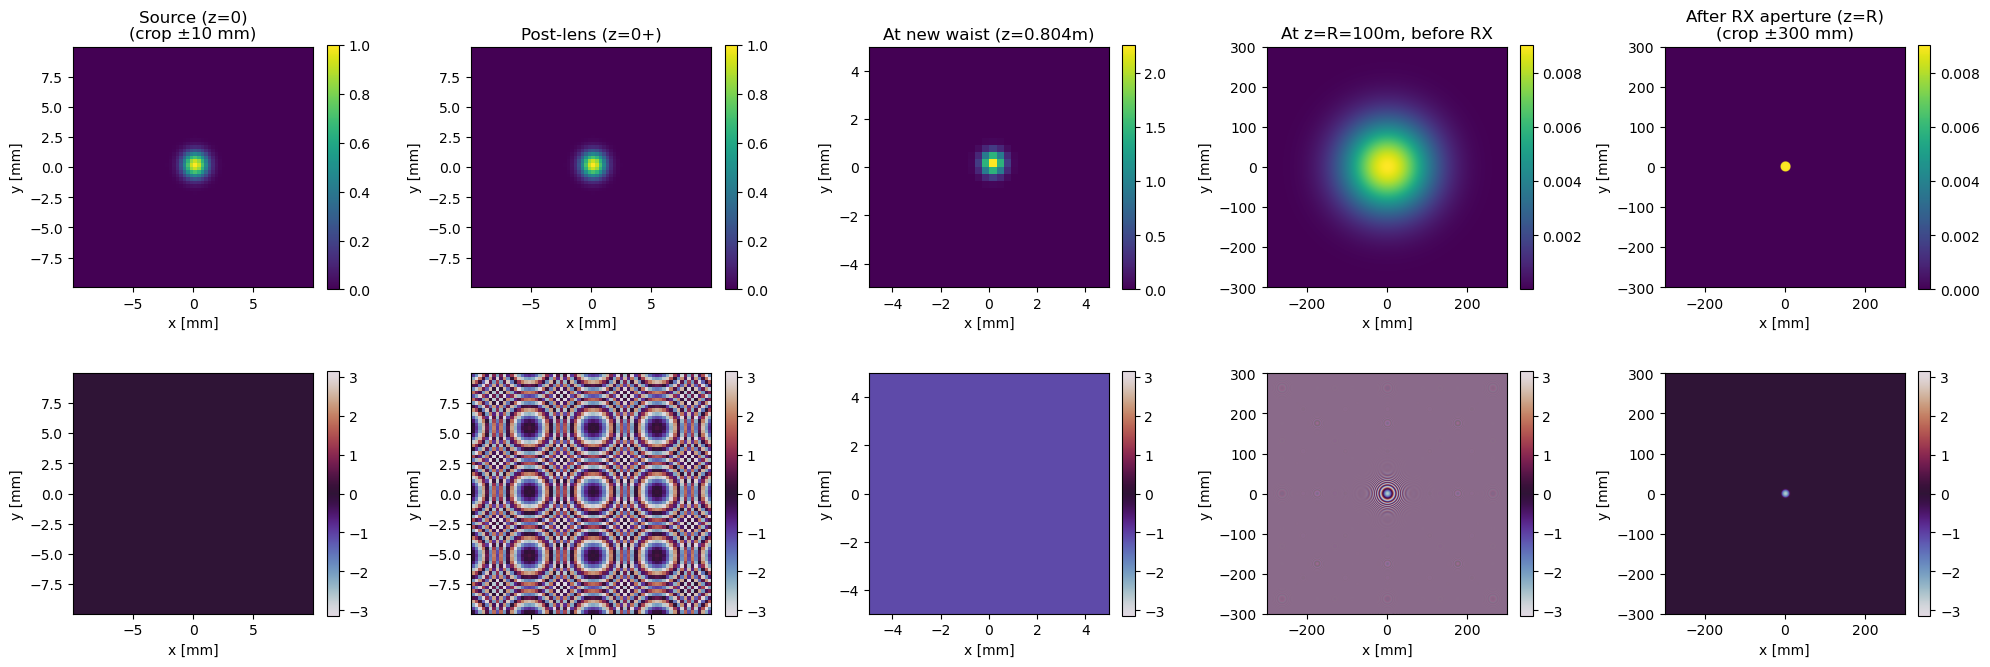

In [11]:
def plot_field(ax_amp, ax_phase, E, title, kz_z=None, crop_mm=None):
    if crop_mm is not None:
        ix_lo = np.argmin(np.abs(x + crop_mm*1e-3))
        ix_hi = np.argmin(np.abs(x - crop_mm*1e-3))
        iy_lo = np.argmin(np.abs(y + crop_mm*1e-3))
        iy_hi = np.argmin(np.abs(y - crop_mm*1e-3))
        E_c = E[iy_lo:iy_hi, ix_lo:ix_hi]
        ext = [x[ix_lo]*1e3, x[ix_hi]*1e3, y[iy_lo]*1e3, y[iy_hi]*1e3]
    else:
        E_c = E
        ext = [-Lx*1e3, Lx*1e3, -Ly*1e3, Ly*1e3]
    if kz_z is not None:
        E_env = E_c * np.exp(-1j * kz_z)
    else:
        E_env = E_c
    im = ax_amp.imshow(np.abs(E_c), origin='lower', extent=ext, cmap='viridis')
    ax_amp.set_title(title)
    ax_amp.set_xlabel('x [mm]'); ax_amp.set_ylabel('y [mm]')
    plt.colorbar(im, ax=ax_amp, fraction=0.046)
    im = ax_phase.imshow(np.angle(E_env), origin='lower', extent=ext, cmap='twilight', vmin=-np.pi, vmax=np.pi)
    ax_phase.set_xlabel('x [mm]'); ax_phase.set_ylabel('y [mm]')
    plt.colorbar(im, ax=ax_phase, fraction=0.046)

stages = [
    ('Source (z=0)',                E_source_direct,           0,             10),
    ('Post-lens (z=0+)',            E_postlens_direct,         0,             10),
    ('At new waist (z=0.804m)',     evaluate_beam_state(post_lens_state, X, Y, k, z=z_w_new),  k*z_w_new, 5),
    ('At z=R=100m, before RX',      E_at_R_GBD,                k*R_target,    300),
    ('After RX aperture (z=R)',     E_at_R_GBD_RX,             k*R_target,    300),
]

fig, axes = plt.subplots(2, len(stages), figsize=(4*len(stages), 7))
for i, (title, E, kz_z, crop) in enumerate(stages):
    plot_field(axes[0, i], axes[1, i], E, title, kz_z=kz_z, crop_mm=crop)
axes[0, 0].set_title(stages[0][0] + '\n(crop ±10 mm)')
axes[0, -1].set_title(stages[-1][0] + '\n(crop ±300 mm)')
plt.tight_layout()
plt.show()

## Summary

If all sanity checks pass:
- **Sanity 1**: source state vs. direct Gaussian → ~1e-15 (state representation correct).
- **Sanity 2**: GBD post-lens vs. source × lens-phase → ~1e-15 (lens-q formula correct).
- **Sanity 3**: GBD vs. AS free-space propagation through several z values → very small relative error (both are exact for a Gaussian; residual is FFT discretization).
- **Apertures**: identical operations in GBD and AS (grid multiplication), so they always agree exactly modulo the propagation step.

**What was demonstrated:**
- Thin lens via per-beamlet q-transformation works at machine precision.
- The lens correctly refocuses a 1 mm Gaussian to a 0.442 mm waist at z = 0.804 m, then re-expands.
- TX aperture has minimal effect on a 1 mm source through 10 mm aperture.
- RX aperture at z = 100 m clips dramatically (only ~2.5% energy through), as predicted for a 110 mm-wide beam through a 25 mm aperture.
- The full optical chain (source → lens → TX aperture → free space → RX aperture) can be tracked through GBD with zero re-decomposition cost (because the source remains Gaussian until the apertures, which are end-of-chain).

**What this notebook deliberately did NOT do** (saving for GBD_13):
- Re-decompose the post-aperture field into a basis. The post-RX-aperture field is non-Gaussian, but we don't need to propagate it further in this notebook — it ends here. GBD_13 will introduce re-decomposition machinery in its natural context (the target return).
- Apply the basis-sum machinery from GBD_10/11. Single-beam analytic suffices for everything before the first non-Gaussian-introducing element. GBD_13 will combine the basis sum with the thin-element framework.
- Add a target. GBD_13.
- Add a scanner. GBD_14.